Total de samples: 108832
Primeiro arquivo: sample_00000.npz
Chaves: ['lidar', 'pose_xy', 'yaw']
LiDAR shape: (360,)
Pose XY: [ 1.8141613 -1.5657154]
Yaw (cos, sin): [ 0.9135462 -0.4067349]
========== DATASET INSPECTION ==========

--- LIDAR ---
Shape: (360,)
Min / Max: 0.04011759 1.0
Primeiros 20 valores: [1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 0.9470657  0.9237311  0.6739225  0.6597965  0.6576424  0.66678363
 0.67654467 0.6868047 ]

--- POSE (x, y) ---
x = 1.8141613
y = -1.5657154

--- YAW ---
cos(yaw): 0.9135462
sin(yaw): -0.4067349
Yaw reconstruído: 336.00°

Abrindo visualizações...


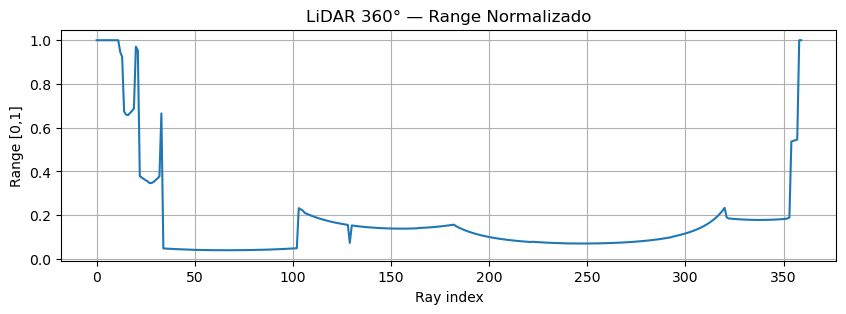

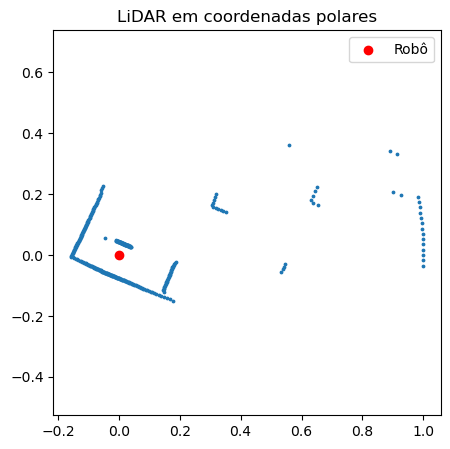

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


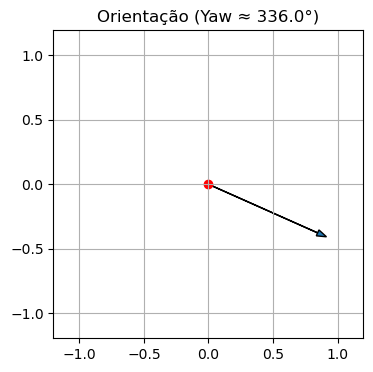

In [7]:
import numpy as np
import math
import matplotlib.pyplot as plt

import numpy as np
import os

dataset_dir = r"C:\Users\User\Documents\IA_PROJECT\Archives\lidar_new_dataset\dataset_lidar_pose"

files = sorted([
    f for f in os.listdir(dataset_dir)
    if f.endswith(".npz")
])

print("Total de samples:", len(files))
print("Primeiro arquivo:", files[0])

data = np.load(os.path.join(dataset_dir, files[30500]))

print("Chaves:", data.files)
print("LiDAR shape:", data["lidar"].shape)
print("Pose XY:", data["pose_xy"])
print("Yaw (cos, sin):", data["yaw"])

print("========== DATASET INSPECTION ==========")


# ---------- LIDAR ----------
lidar = data["lidar"]
print("\n--- LIDAR ---")
print("Shape:", lidar.shape)
print("Min / Max:", lidar.min(), lidar.max())
print("Primeiros 20 valores:", lidar[:20])

# ---------- POSE ----------
pose_xy = data["pose_xy"]
print("\n--- POSE (x, y) ---")
print("x =", pose_xy[0])
print("y =", pose_xy[1])

# ---------- YAW ----------
yaw_vec = data["yaw"]
cos_yaw, sin_yaw = yaw_vec

yaw_rad = math.atan2(sin_yaw, cos_yaw)
yaw_deg = math.degrees(yaw_rad)
if yaw_deg < 0:
    yaw_deg += 360

print("\n--- YAW ---")
print("cos(yaw):", cos_yaw)
print("sin(yaw):", sin_yaw)
print(f"Yaw reconstruído: {yaw_deg:.2f}°")

# ---------- VISUALIZAÇÕES ----------
print("\nAbrindo visualizações...")

# LIDAR como sinal 1D
plt.figure(figsize=(10, 3))
plt.plot(lidar)
plt.title("LiDAR 360° — Range Normalizado")
plt.xlabel("Ray index")
plt.ylabel("Range [0,1]")
plt.grid(True)
plt.show()

# LIDAR em polar
angles = np.linspace(0, 2 * np.pi, lidar.shape[0], endpoint=False)
x = lidar * np.cos(angles)
y = lidar * np.sin(angles)

plt.figure(figsize=(5, 5))
plt.scatter(x, y, s=3)
plt.scatter(0, 0, c="red", label="Robô")
plt.axis("equal")
plt.title("LiDAR em coordenadas polares")
plt.legend()
plt.show()

# Yaw como seta
plt.figure(figsize=(4, 4))
plt.arrow(
    0, 0,
    cos_yaw, sin_yaw,
    head_width=0.05,
    length_includes_head=True
)
plt.scatter(0, 0, c="red")
plt.axis("equal")
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.title(f"Orientação (Yaw ≈ {yaw_deg:.1f}°)")
plt.grid(True)
plt.show()




Arquivos .npz encontrados: 108832
Amostrando 108000 arquivos (stride=1, max_samples=108000, random=False)


  0%|          | 0/108000 [00:00<?, ?it/s]

Arquivos válidos processados: 108000 (invalidos: 0)

--- Resumos ---
Pose X: N=108000, mean=-1.1773, std=1.8209, min=-4.0973, max=2.5543
Pose Y: N=108000, mean=0.0217, std=0.8426, min=-1.8452, max=1.7761
Yaw (deg): N=108000, mean=180.0593, std=103.0451, min=0.0004, max=359.9927
LiDAR min: N=108000, mean=0.0962, std=0.0494, min=0.0091, max=0.2599
LiDAR mean: N=108000, mean=0.3613, std=0.0564, min=0.1073, max=0.4510
LiDAR max: N=108000, mean=0.9599, std=0.0722, min=0.2675, max=1.0000

Bounding box: x ∈ [-4.10, 2.55], y ∈ [-1.85, 1.78], area=24.0870
Convex hull area: 23.3569 (pontos no hull: 33)
Mean nearest neighbor distance (amostrado): mean=0.0038, median=0.0047


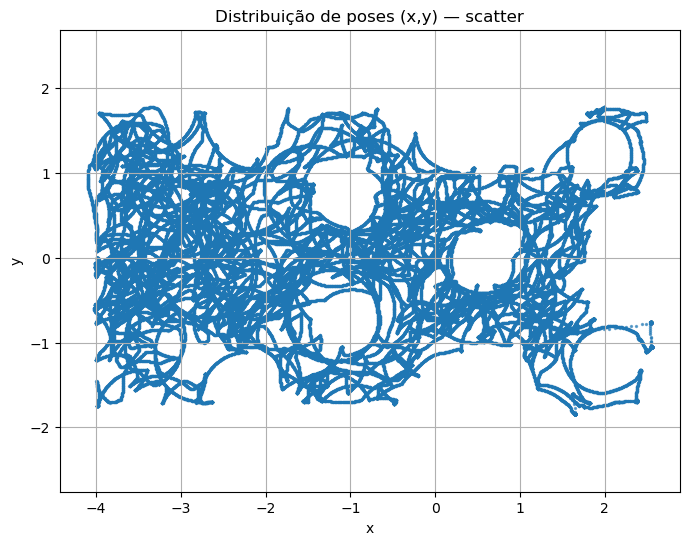

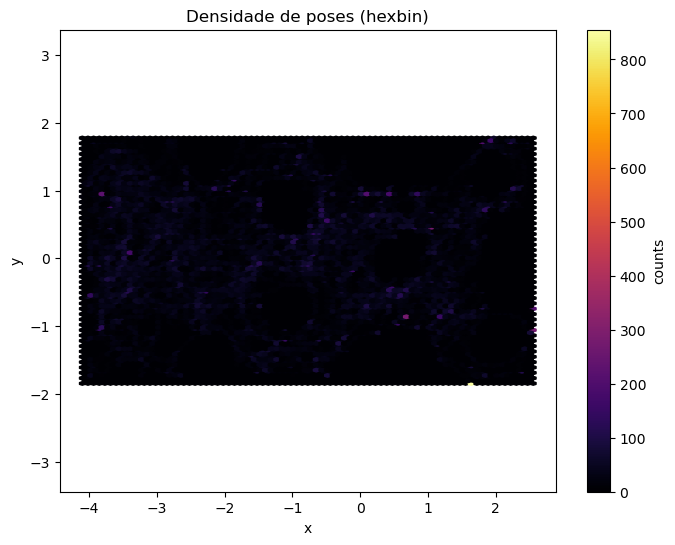

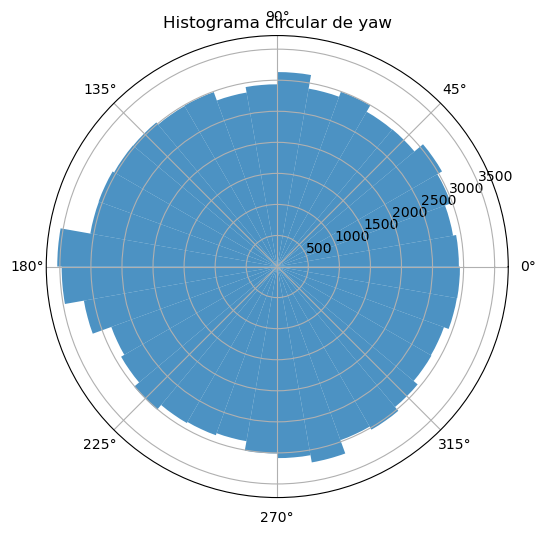

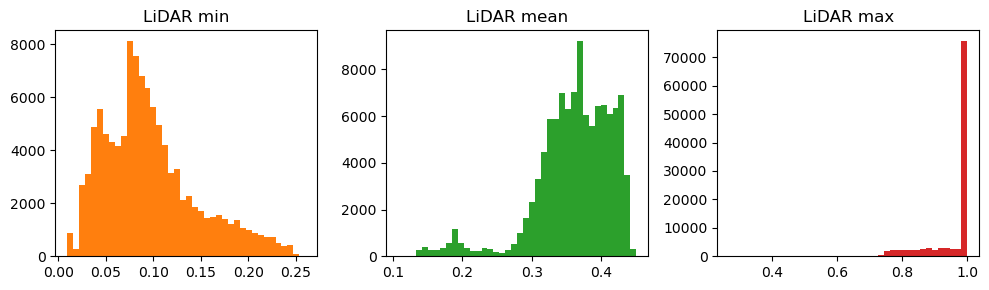

In [ ]:
# --- Parâmetros (ajuste conforme necessário) ---
dataset_dir = r"C:\Users\User\Documents\IA_PROJECT\Archives\lidar_new_dataset\dataset_lidar_pose"
max_samples = 10800    # número máximo de arquivos a processar (None = todos)
sample_stride = 1         # use 1 para pegar todos, 10 para amostrar 1 em 10, etc.
random_sample = False     # se True, seleciona uma amostra aleatória de max_samples
random_seed = 42


from collections import defaultdict

# tqdm (opcional)
try:
    from tqdm.auto import tqdm
    _tqdm = tqdm
except Exception:
    _tqdm = lambda x: x

# ferramentas opcionais
_has_scipy = True
try:
    from scipy.spatial import ConvexHull, cKDTree
except Exception:
    _has_scipy = False

# --- Coleta lista de arquivos ---
files = sorted([f for f in os.listdir(dataset_dir) if f.endswith('.npz')])
n_total = len(files)
print(f"Arquivos .npz encontrados: {n_total}")

# --- Seleção de amostra ---
if max_samples is not None and max_samples < n_total:
    if random_sample:
        rng = np.random.RandomState(random_seed)
        indices = rng.choice(n_total, size=max_samples, replace=False)
        indices = np.sort(indices)
    else:
        indices = np.arange(0, min(n_total, max_samples*sample_stride), sample_stride)[:max_samples]
else:
    indices = np.arange(0, n_total, sample_stride)

print(f"Amostrando {len(indices)} arquivos (stride={sample_stride}, max_samples={max_samples}, random={random_sample})")

# --- Containers ---
xs, ys, yaws_deg = [], [], []
lidar_min, lidar_mean, lidar_max = [], [], []
invalid_count = 0

# --- Loop de leitura ---
for i in _tqdm(indices):
    path = os.path.join(dataset_dir, files[i])
    try:
        data = np.load(path)
    except Exception as e:
        print(f"Falha ao abrir {files[i]}: {e}")
        continue

    # pose
    pose = data.get("pose_xy")
    if pose is None:
        invalid_count += 1
        continue
    x, y = float(pose[0]), float(pose[1])
    xs.append(x); ys.append(y)

    # yaw (cos, sin) -> graus [0,360)
    yawv = data.get("yaw")
    if yawv is not None:
        cos_y, sin_y = float(yawv[0]), float(yawv[1])
        ang = math.degrees(math.atan2(sin_y, cos_y))
        if ang < 0:
            ang += 360
        yaws_deg.append(ang)
    else:
        yaws_deg.append(np.nan)

    # lidar estatísticas
    lidar = data.get("lidar")
    if lidar is not None:
        lidar_min.append(float(np.nanmin(lidar)))
        lidar_mean.append(float(np.nanmean(lidar)))
        lidar_max.append(float(np.nanmax(lidar)))
    else:
        lidar_min.append(np.nan); lidar_mean.append(np.nan); lidar_max.append(np.nan)

# --- Converte para arrays ---
xs = np.array(xs); ys = np.array(ys); yaws_deg = np.array(yaws_deg)
lidar_min = np.array(lidar_min); lidar_mean = np.array(lidar_mean); lidar_max = np.array(lidar_max)

print(f"Arquivos válidos processados: {len(xs)} (invalidos: {invalid_count})")

# --- Estatísticas simples ---
def summary(arr, name):
    arr = np.array(arr)[~np.isnan(arr)]
    if arr.size == 0:
        print(f"{name}: sem dados")
        return
    print(f"{name}: N={arr.size}, mean={arr.mean():.4f}, std={arr.std():.4f}, min={arr.min():.4f}, max={arr.max():.4f}")

print("\n--- Resumos ---")
summary(xs, "Pose X")
summary(ys, "Pose Y")
summary(yaws_deg, "Yaw (deg)")
summary(lidar_min, "LiDAR min")
summary(lidar_mean, "LiDAR mean")
summary(lidar_max, "LiDAR max")

# bounding box e área aproximada
if xs.size > 0:
    xmin, xmax = xs.min(), xs.max()
    ymin, ymax = ys.min(), ys.max()
    bbox_area = (xmax - xmin) * (ymax - ymin)
    print(f"\nBounding box: x ∈ [{xmin:.2f}, {xmax:.2f}], y ∈ [{ymin:.2f}, {ymax:.2f}], area={bbox_area:.4f}")

# convex hull area (se scipy disponível)
if _has_scipy and xs.size >= 3:
    try:
        pts = np.vstack([xs, ys]).T
        hull = ConvexHull(pts)
        print(f"Convex hull area: {hull.volume:.4f} (pontos no hull: {len(hull.vertices)})")
    except Exception as e:
        print("Convex hull falhou:", e)
else:
    print("Convex hull não disponível (scipy ausente ou poucos pontos)")

# --- Distância ao vizinho mais próximo (amostra para performance) ---
def mean_nearest_neighbor(points, sample_n=2000):
    if points.shape[0] < 2:
        return np.nan
    if _has_scipy:
        tree = cKDTree(points)
        k = min(points.shape[0], sample_n)
        idx = np.random.choice(points.shape[0], size=k, replace=False)
        d, _ = tree.query(points[idx], k=2)  # k=2 -> [self, nearest]
        nn = d[:,1]
        return nn.mean(), np.median(nn)
    else:
        return np.nan, np.nan

if xs.size > 1:
    mn_mean, mn_median = mean_nearest_neighbor(np.vstack([xs, ys]).T, sample_n=2000)
    print(f"Mean nearest neighbor distance (amostrado): mean={mn_mean:.4f}, median={mn_median:.4f}")

# --- Visualizações ---
plt.figure(figsize=(8,6))
plt.scatter(xs, ys, s=2, alpha=0.6)
plt.title("Distribuição de poses (x,y) — scatter")
plt.xlabel("x"); plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.show()

# density (hexbin)
plt.figure(figsize=(8,6))
plt.hexbin(xs, ys, gridsize=80, cmap='inferno')
plt.colorbar(label='counts')
plt.title("Densidade de poses (hexbin)")
plt.xlabel("x"); plt.ylabel("y")
plt.axis("equal")
plt.show()

# Yaw circular histogram (rose)
valid_yaws = yaws_deg[~np.isnan(yaws_deg)]
if valid_yaws.size > 0:
    plt.figure(figsize=(6,6))
    ax = plt.subplot(projection='polar')
    bins = 36
    angles = np.deg2rad(valid_yaws)
    counts, bin_edges = np.histogram(angles, bins=bins)
    widths = np.diff(bin_edges)
    ax.bar(bin_edges[:-1], counts, width=widths, bottom=0.0, align='edge', color='C0', alpha=0.8)
    ax.set_title("Histograma circular de yaw")
    plt.show()

# LiDAR distributions
plt.figure(figsize=(10,3))
plt.subplot(1,3,1); plt.hist(lidar_min[~np.isnan(lidar_min)], bins=40, color='C1'); plt.title("LiDAR min")
plt.subplot(1,3,2); plt.hist(lidar_mean[~np.isnan(lidar_mean)], bins=40, color='C2'); plt.title("LiDAR mean")
plt.subplot(1,3,3); plt.hist(lidar_max[~np.isnan(lidar_max)], bins=40, color='C3'); plt.title("LiDAR max")
plt.tight_layout(); plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

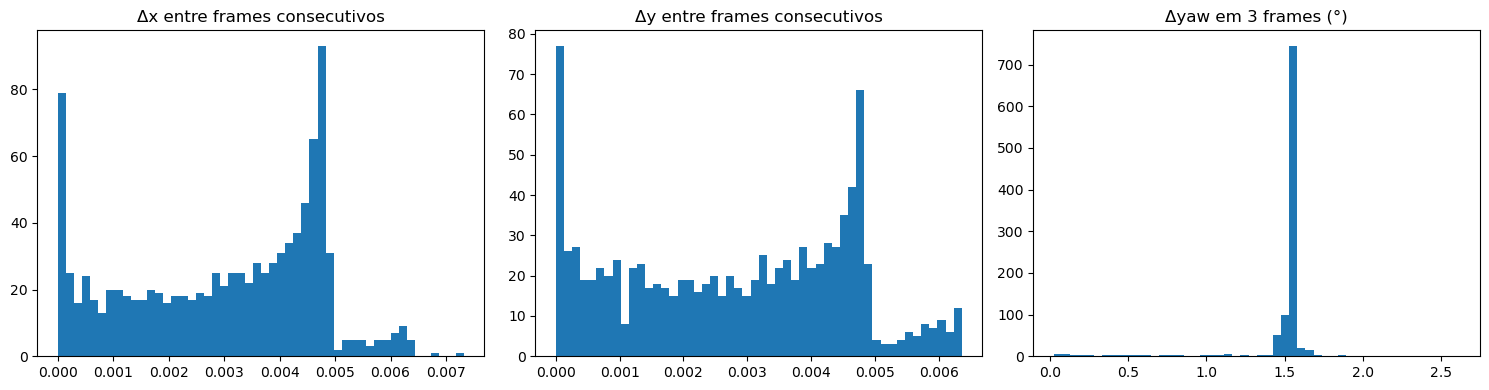

Deslocamento médio/frame: 0.0030m (x), 0.0028m (y)
Rotação média/3frames: 1.5°


In [ ]:
# Verifica se frames consecutivos são muito correlacionados
deltas_x = []
deltas_y = []
delta_yaw = []

for i in tqdm(range(0, min(10000, len(files)-3), 10)):  # amostra
    d0 = np.load(os.path.join(dataset_dir, files[i]))
    d1 = np.load(os.path.join(dataset_dir, files[i+1]))
    d3 = np.load(os.path.join(dataset_dir, files[i+3]))
    
    # Deslocamento 1 frame
    dx1 = d1["pose_xy"][0] - d0["pose_xy"][0]
    dy1 = d1["pose_xy"][1] - d0["pose_xy"][1]
    deltas_x.append(abs(dx1))
    deltas_y.append(abs(dy1))
    
    # Yaw change
    yaw0 = math.atan2(d0["yaw"][1], d0["yaw"][0])
    yaw3 = math.atan2(d3["yaw"][1], d3["yaw"][0])
    dyaw = abs(yaw3 - yaw0)
    if dyaw > math.pi: dyaw = 2*math.pi - dyaw
    delta_yaw.append(math.degrees(dyaw))

# Visualização
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(deltas_x, bins=50); axes[0].set_title("Δx entre frames consecutivos")
axes[1].hist(deltas_y, bins=50); axes[1].set_title("Δy entre frames consecutivos")
axes[2].hist(delta_yaw, bins=50); axes[2].set_title("Δyaw em 3 frames (°)")
plt.tight_layout(); plt.show()

print(f"Deslocamento médio/frame: {np.mean(deltas_x):.4f}m (x), {np.mean(deltas_y):.4f}m (y)")
print(f"Rotação média/3frames: {np.mean(delta_yaw):.1f}°")

  0%|          | 0/1000 [00:00<?, ?it/s]

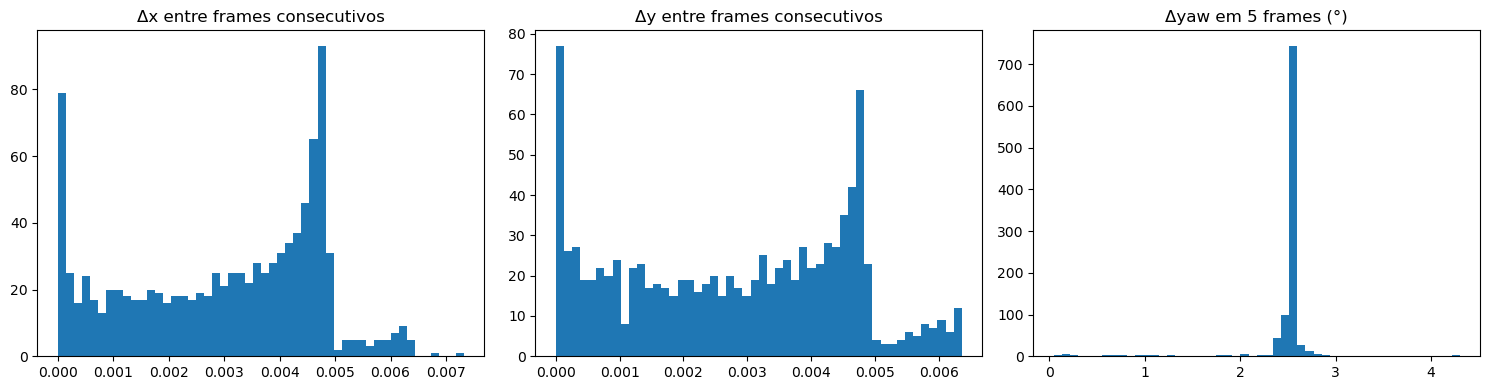

Deslocamento médio/frame: 0.0030m (x), 0.0028m (y)
Rotação média/3frames: 2.5°


In [19]:
# Verifica se frames consecutivos são muito correlacionados
deltas_x = []
deltas_y = []
delta_yaw = []

for i in tqdm(range(0, min(10000, len(files)-5), 10)):  # amostra
    d0 = np.load(os.path.join(dataset_dir, files[i]))
    d1 = np.load(os.path.join(dataset_dir, files[i+1]))
    d3 = np.load(os.path.join(dataset_dir, files[i+5]))
    
    # Deslocamento 1 frame
    dx1 = d1["pose_xy"][0] - d0["pose_xy"][0]
    dy1 = d1["pose_xy"][1] - d0["pose_xy"][1]
    deltas_x.append(abs(dx1))
    deltas_y.append(abs(dy1))
    
    # Yaw change
    yaw0 = math.atan2(d0["yaw"][1], d0["yaw"][0])
    yaw3 = math.atan2(d3["yaw"][1], d3["yaw"][0])
    dyaw = abs(yaw3 - yaw0)
    if dyaw > math.pi: dyaw = 2*math.pi - dyaw
    delta_yaw.append(math.degrees(dyaw))

# Visualização
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(deltas_x, bins=50); axes[0].set_title("Δx entre frames consecutivos")
axes[1].hist(deltas_y, bins=50); axes[1].set_title("Δy entre frames consecutivos")
axes[2].hist(delta_yaw, bins=50); axes[2].set_title("Δyaw em 5 frames (°)")
plt.tight_layout(); plt.show()

print(f"Deslocamento médio/frame: {np.mean(deltas_x):.4f}m (x), {np.mean(deltas_y):.4f}m (y)")
print(f"Rotação média/3frames: {np.mean(delta_yaw):.1f}°")

  0%|          | 0/108832 [00:00<?, ?it/s]

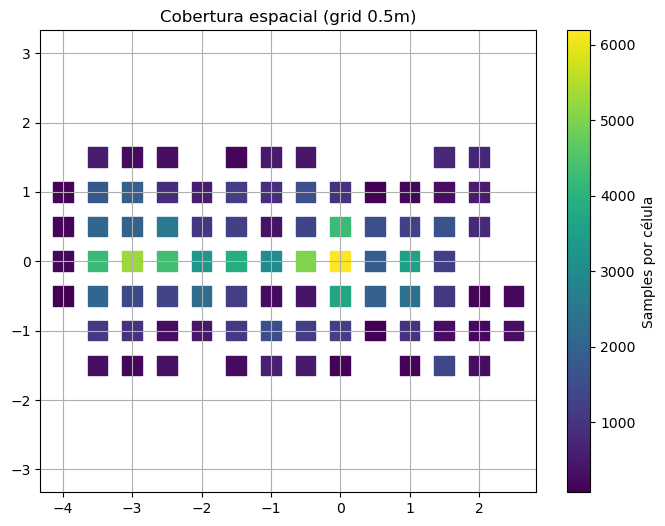

Células cobertas: 83
Min/Max samples: 75 / 6191


In [14]:
# Divide em grid e conta samples por célula
grid_size = 0.5  # células de 50cm
grid_counts = defaultdict(int)

for i in tqdm(range(0, len(files), 1)):
    d = np.load(os.path.join(dataset_dir, files[i]))
    gx = int(d["pose_xy"][0] / grid_size)
    gy = int(d["pose_xy"][1] / grid_size)
    grid_counts[(gx, gy)] += 1

# Visualização
gxs = [k[0]*grid_size for k in grid_counts.keys()]
gys = [k[1]*grid_size for k in grid_counts.keys()]
counts = list(grid_counts.values())

plt.figure(figsize=(8, 6))
plt.scatter(gxs, gys, c=counts, s=200, cmap='viridis', marker='s')
plt.colorbar(label='Samples por célula')
plt.title(f"Cobertura espacial (grid {grid_size}m)")
plt.axis('equal'); plt.grid(True); plt.show()

print(f"Células cobertas: {len(grid_counts)}")
print(f"Min/Max samples: {min(counts)} / {max(counts)}")

  0%|          | 0/1089 [00:00<?, ?it/s]

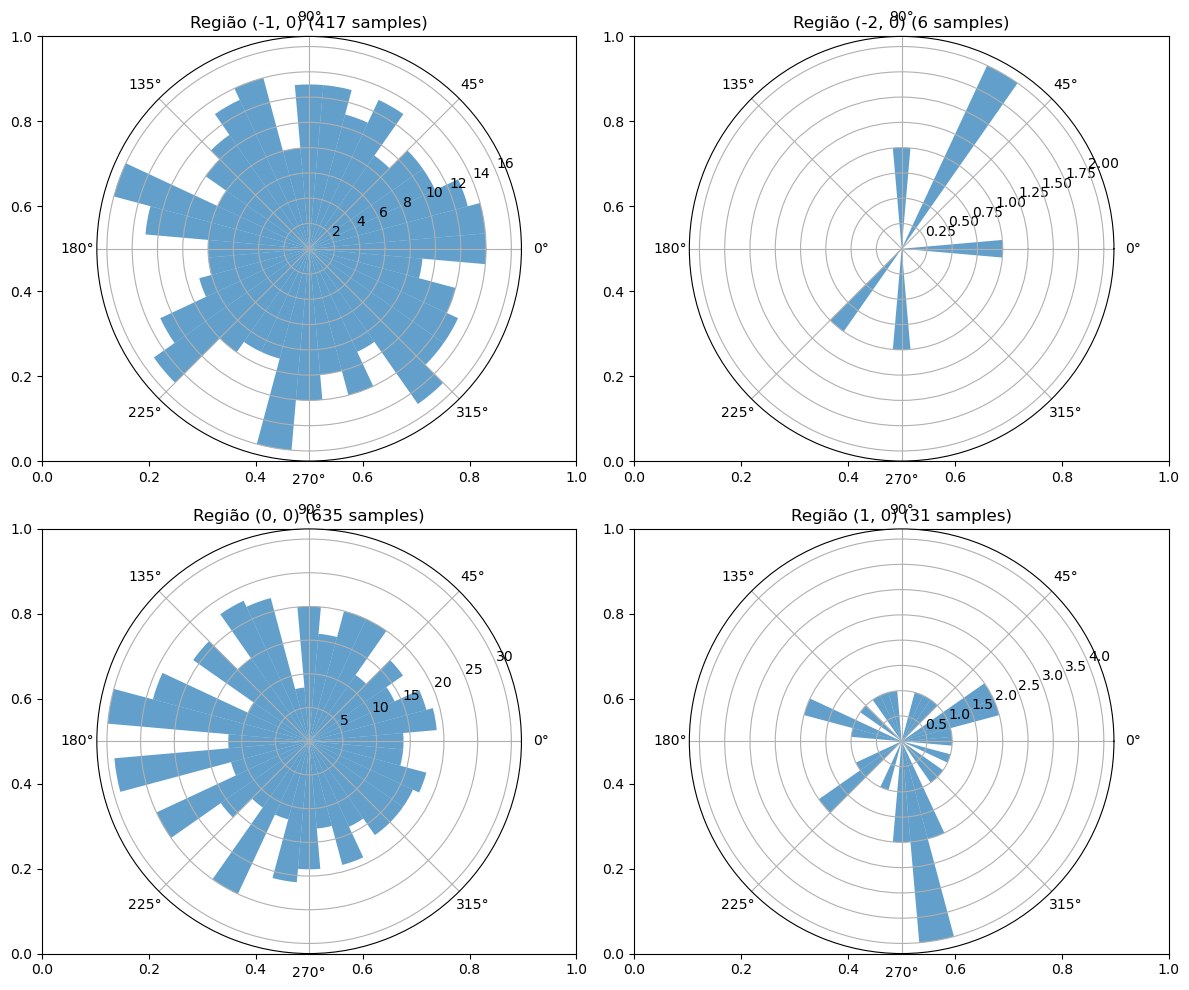

In [11]:
# Verifica se todas regiões têm cobertura angular
regions = defaultdict(list)

for i in tqdm(range(0, len(files), 100)):
    d = np.load(os.path.join(dataset_dir, files[i]))
    x, y = d["pose_xy"]
    region = (int(x/2), int(y/2))  # regiões de 2m
    yaw = math.degrees(math.atan2(d["yaw"][1], d["yaw"][0]))
    if yaw < 0: yaw += 360
    regions[region].append(yaw)

# Verifica uniformidade angular por região
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (region, yaws) in enumerate(list(regions.items())[:4]):
    ax = plt.subplot(2, 2, idx+1, projection='polar')
    counts, bins = np.histogram(yaws, bins=36, range=(0, 360))
    ax.bar(np.deg2rad(bins[:-1]), counts, width=np.deg2rad(10), alpha=0.7)
    ax.set_title(f"Região {region} ({len(yaws)} samples)")
plt.tight_layout(); plt.show()

  0%|          | 0/80000 [00:00<?, ?it/s]

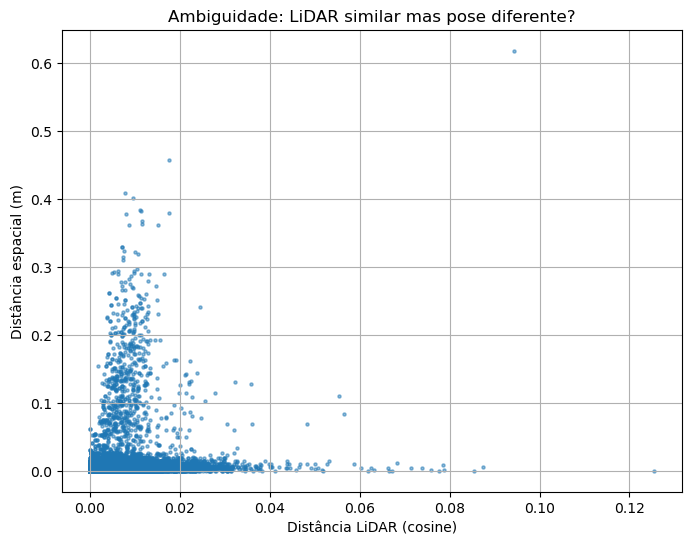

Samples ambíguos (>1m): 0/80000 (0.0%)


In [17]:
# Encontra poses diferentes com LiDAR similar (potenciais confusões)
from sklearn.neighbors import NearestNeighbors

sample_idx = np.random.choice(len(files), 80000, replace=False)
poses = []
lidars = []

for i in tqdm(sample_idx):
    d = np.load(os.path.join(dataset_dir, files[i]))
    poses.append(d["pose_xy"])
    lidars.append(d["lidar"])

poses = np.array(poses)
lidars = np.array(lidars)

# Nearest neighbors no espaço LiDAR
nn = NearestNeighbors(n_neighbors=5, metric='cosine')
nn.fit(lidars)
distances, indices = nn.kneighbors(lidars)

# Para cada ponto, distância espacial ao vizinho LiDAR mais próximo
ambiguities = []
for i in range(len(poses)):
    nearest = indices[i][1]  # mais próximo (exceto self)
    spatial_dist = np.linalg.norm(poses[i] - poses[nearest])
    lidar_dist = distances[i][1]
    ambiguities.append((spatial_dist, lidar_dist))

ambiguities = np.array(ambiguities)

plt.figure(figsize=(8, 6))
plt.scatter(ambiguities[:, 1], ambiguities[:, 0], s=5, alpha=0.5)
plt.xlabel("Distância LiDAR (cosine)")
plt.ylabel("Distância espacial (m)")
plt.title("Ambiguidade: LiDAR similar mas pose diferente?")
plt.grid(True); plt.show()

# Casos problemáticos
problematic = ambiguities[:, 0] > 1  # >1m de diferença
print(f"Samples ambíguos (>1m): {problematic.sum()}/{len(ambiguities)} ({100*problematic.sum()/len(ambiguities):.1f}%)")

In [18]:
# Métricas para reportar
very_close = (ambiguities[:, 1] < 0.01) & (ambiguities[:, 0] < 0.1)
ambiguous = (ambiguities[:, 1] < 0.05) & (ambiguities[:, 0] > 0.5)

print(f"✅ Poses próximas: {100*very_close.sum()/len(ambiguities):.1f}%")
print(f"❌ Casos ambíguos: {100*ambiguous.sum()/len(ambiguities):.2f}%")

✅ Poses próximas: 94.6%
❌ Casos ambíguos: 0.00%
